In [1]:
# Практика 16. Кореляційний аналіз
# Коць Артем, ІТ-42
# Варіант 9 — Суми

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

np.random.seed(9)

variant = 9
city = "Суми"

monthly_temp = [-6, -5, 0, 9, 15, 18, 20, 19, 13, 7, 1, -4]

months = [
    "Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
    "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"
]

rows = []

for month, temp in zip(months, monthly_temp):
    heating_days = np.clip(
        18 - temp + np.random.normal(0, 1.5),
        0,
        30
    )
    heating_days = round(heating_days)

    cost = 0.15 * heating_days + np.random.normal(0, 1.0)
    cost = round(max(cost, 0), 1)

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": temp,
        "опалювальні_дні": heating_days,
        "витрати_на_опалення": cost
    })

climate = pd.DataFrame(rows)

print("Студент: Коць Артем")
print("Група: ІТ-42")
print("Варіант:", variant)
print("Місто:", city)
print("Кількість рядків:", len(climate))

display(climate)

Студент: Коць Артем
Група: ІТ-42
Варіант: 9
Місто: Суми
Кількість рядків: 12


,місто,місяць,температура,опалювальні_дні,витрати_на_опалення
0,Суми,Січ,-6,24,3.3
1,Суми,Лют,-5,21,3.1
2,Суми,Бер,0,17,2.1
3,Суми,Кві,9,7,0.6
4,Суми,Тра,15,3,0.0
5,Суми,Чер,18,1,1.9
6,Суми,Лип,20,0,0.7
7,Суми,Сер,19,2,0.7
8,Суми,Вер,13,7,0.1
9,Суми,Жов,7,11,2.9


In [2]:
print("Розмір DataFrame:", climate.shape)

print("\nТипи даних:")
print(climate.dtypes)

print("\nПропуски:")
print(climate.isna().sum())

Розмір DataFrame: (12, 5)

Типи даних:
місто                      str
місяць                     str
температура              int64
опалювальні_дні          int64
витрати_на_опалення    float64
dtype: object

Пропуски:
місто                  0
місяць                 0
температура            0
опалювальні_дні        0
витрати_на_опалення    0
dtype: int64


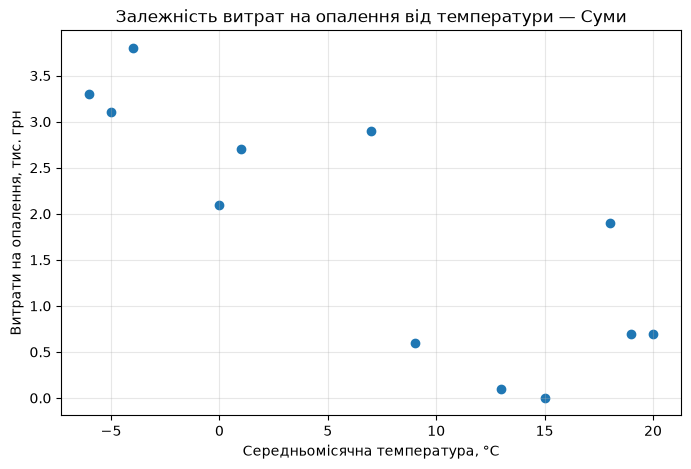

In [3]:
# Завдання 1. Діаграма розсіювання

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    climate["температура"],
    climate["витрати_на_опалення"]
)

ax.set_xlabel("Середньомісячна температура, °C")
ax.set_ylabel("Витрати на опалення, тис. грн")
ax.set_title("Залежність витрат на опалення від температури — Суми")
ax.grid(True, alpha=0.3)

plt.show()

### Завдання 1. Аналіз діаграми розсіювання

На діаграмі спостерігається негативний зв'язок між температурою та витратами на опалення: зі зниженням температури витрати на опалення загалом збільшуються.

Хмара точок має приблизно лінійний характер. Точки не розташовані точно на одній прямій через випадковий шум, який був доданий під час генерації даних.

Явних сильних викидів у початковому наборі даних не спостерігається.

Такий напрямок зв'язку відповідає логіці генерації даних. Кількість опалювальних днів розраховується на основі температури за формулою `18 - temp`, тому нижча температура призводить до більшої кількості опалювальних днів. Витрати на опалення, у свою чергу, залежать від кількості опалювальних днів.

In [4]:
# Завдання 2. Коефіцієнти Пірсона і Спірмена

pearson_result = pearsonr(
    climate["температура"],
    climate["витрати_на_опалення"]
)

spearman_result = spearmanr(
    climate["температура"],
    climate["витрати_на_опалення"]
)

print(
    f"Пірсон: r = {pearson_result.statistic:.3f}, "
    f"p-value = {pearson_result.pvalue:.4f}"
)

print(
    f"Спірмен: rho = {spearman_result.statistic:.3f}, "
    f"p-value = {spearman_result.pvalue:.4f}"
)

ci = pearson_result.confidence_interval(confidence_level=0.95)

print(f"\n95% ДІ для r: [{ci.low:.3f}; {ci.high:.3f}]")

Пірсон: r = -0.812, p-value = 0.0014
Спірмен: rho = -0.760, p-value = 0.0041

95% ДІ для r: [-0.945; -0.445]


In [5]:
alpha = 0.05

print("Перевірка гіпотез при α = 0.05")

if pearson_result.pvalue < alpha:
    print("Пірсон: H0 відхиляємо — статистично значущий лінійний зв'язок є.")
else:
    print("Пірсон: H0 не відхиляємо — статистично значущого лінійного зв'язку не виявлено.")

if spearman_result.pvalue < alpha:
    print("Спірмен: H0 відхиляємо — статистично значущий монотонний зв'язок є.")
else:
    print("Спірмен: H0 не відхиляємо — статистично значущого монотонного зв'язку не виявлено.")

Перевірка гіпотез при α = 0.05
Пірсон: H0 відхиляємо — статистично значущий лінійний зв'язок є.
Спірмен: H0 відхиляємо — статистично значущий монотонний зв'язок є.


### Інтерпретація результатів

Коефіцієнт Пірсона `r` характеризує силу та напрямок лінійного зв'язку між температурою і витратами на опалення.

Коефіцієнт Спірмена `rho` характеризує силу та напрямок монотонного зв'язку на основі рангів.

При рівні значущості α = 0.05 нульова гіпотеза відхиляється, якщо `p-value < 0.05`.

Отримані значення показують сильний негативний зв'язок: при збільшенні температури витрати на опалення зменшуються. Значення Пірсона та Спірмена є близькими, оскільки залежність у згенерованих даних переважно монотонна та приблизно лінійна.

95% довірчий інтервал для коефіцієнта Пірсона показує діапазон правдоподібних значень істинного коефіцієнта кореляції в генеральній сукупності.

In [6]:
# Завдання 3. Кореляційна матриця Пірсона

corr_data = climate[
    ["температура", "опалювальні_дні", "витрати_на_опалення"]
]

print("Кореляційна матриця Пірсона:")
display(corr_data.corr().round(3))

Кореляційна матриця Пірсона:


,температура,опалювальні_дні,витрати_на_опалення
температура,1.000,-0.990,-0.812
опалювальні_дні,-0.990,1.000,0.833
витрати_на_опалення,-0.812,0.833,1.000


In [7]:
print("Кореляційна матриця Спірмена:")
display(
    corr_data.corr(method="spearman").round(3)
)

Кореляційна матриця Спірмена:


,температура,опалювальні_дні,витрати_на_опалення
температура,1.000,-0.977,-0.760
опалювальні_дні,-0.977,1.000,0.768
витрати_на_опалення,-0.760,0.768,1.000


In [8]:
corr_matrix = corr_data.corr()

pairs = {
    "температура — опалювальні дні": abs(corr_matrix.loc["температура", "опалювальні_дні"]),
    "температура — витрати": abs(corr_matrix.loc["температура", "витрати_на_опалення"]),
    "опалювальні дні — витрати": abs(corr_matrix.loc["опалювальні_дні", "витрати_на_опалення"])
}

strongest = max(pairs, key=pairs.get)
weakest = min(pairs, key=pairs.get)

print("Найсильніший зв'язок:", strongest)
print("Значення:", pairs[strongest])

print("\nНайслабший зв'язок:", weakest)
print("Значення:", pairs[weakest])

Найсильніший зв'язок: температура — опалювальні дні
Значення: 0.9895646469304513

Найслабший зв'язок: температура — витрати
Значення: 0.8115189154792207


### Аналіз кореляційної матриці

Кореляційна матриця показує силу та напрямок зв'язку між температурою, кількістю опалювальних днів і витратами на опалення.

Між температурою та опалювальними днями спостерігається сильний негативний зв'язок: при зростанні температури кількість днів опалення зменшується.

Між опалювальними днями та витратами на опалення спостерігається позитивний зв'язок: більша кількість опалювальних днів призводить до більших витрат.

Між температурою та витратами на опалення спостерігається негативний зв'язок.

Ці залежності є очікуваними, оскільки `опалювальні_дні` та `витрати_на_опалення` були згенеровані на основі температури та кількості опалювальних днів.

## Завдання 4. Кореляція та причинність

Кореляція показує статистичний зв'язок між змінними, але сама по собі не доводить причинно-наслідковий зв'язок.

У нашому наборі даних залежність частково закладена безпосередньо під час генерації даних. Кількість `опалювальних_днів` розраховується за температурою за формулою `18 - temp`, а `витрати_на_опалення` залежать від кількості опалювальних днів за формулою `0.15 * heating_days` з додаванням випадкового шуму.

Тому в цьому синтетичному наборі ми очікуємо сильну кореляцію між температурою, опалювальними днями та витратами.

Проте в реальних даних сильна кореляція не означає автоматично причинність. На витрати на опалення можуть одночасно впливати площа будинку, якість утеплення, ціни на паливо, тип опалення та інші фактори.

Прикладом хибного висновку є зв'язок між продажами морозива та кількістю випадків утоплення. Обидва показники можуть зростати влітку, але морозиво не є причиною утоплень. Спільною причиною є тепла пора року, яка впливає на обидві змінні.

In [9]:
# Завдання 5. Додавання аномального спостереження

# Беремо рядок із найбільшими початковими витратами
anomaly = climate.loc[
    climate["витрати_на_опалення"].idxmax()
].copy()

# Позначаємо аварійну ситуацію
anomaly["місяць"] = anomaly["місяць"] + "_аварія"

# Збільшуємо витрати у 5 разів
anomaly["витрати_на_опалення"] = round(
    anomaly["витрати_на_опалення"] * 5,
    1
)

# Додаємо аномальний рядок
climate_anomaly = pd.concat(
    [climate, pd.DataFrame([anomaly])],
    ignore_index=True
)

display(climate_anomaly)

,місто,місяць,температура,опалювальні_дні,витрати_на_опалення
0,Суми,Січ,-6,24,3.3
1,Суми,Лют,-5,21,3.1
2,Суми,Бер,0,17,2.1
3,Суми,Кві,9,7,0.6
4,Суми,Тра,15,3,0.0
5,Суми,Чер,18,1,1.9
6,Суми,Лип,20,0,0.7
7,Суми,Сер,19,2,0.7
8,Суми,Вер,13,7,0.1
9,Суми,Жов,7,11,2.9


In [10]:
# Кореляції до додавання аномалії

pearson_original = pearsonr(
    climate["температура"],
    climate["витрати_на_опалення"]
)

spearman_original = spearmanr(
    climate["температура"],
    climate["витрати_на_опалення"]
)

# Кореляції після додавання аномалії

pearson_anomaly = pearsonr(
    climate_anomaly["температура"],
    climate_anomaly["витрати_на_опалення"]
)

spearman_anomaly = spearmanr(
    climate_anomaly["температура"],
    climate_anomaly["витрати_на_опалення"]
)

print("До додавання аномалії:")
print(f"Пірсон:  r = {pearson_original.statistic:.3f}")
print(f"Спірмен: rho = {spearman_original.statistic:.3f}")

print("\nПісля додавання аномалії:")
print(f"Пірсон:  r = {pearson_anomaly.statistic:.3f}")
print(f"Спірмен: rho = {spearman_anomaly.statistic:.3f}")

До додавання аномалії:
Пірсон:  r = -0.812
Спірмен: rho = -0.760

Після додавання аномалії:
Пірсон:  r = -0.506
Спірмен: rho = -0.782


In [11]:
pearson_change = (
    pearson_anomaly.statistic -
    pearson_original.statistic
)

spearman_change = (
    spearman_anomaly.statistic -
    spearman_original.statistic
)

print(f"Зміна Пірсона:  {pearson_change:+.3f}")
print(f"Зміна Спірмена: {spearman_change:+.3f}")

if abs(pearson_change) > abs(spearman_change):
    print("\nБільше змінився коефіцієнт Пірсона.")
else:
    print("\nБільше змінився коефіцієнт Спірмена.")

Зміна Пірсона:  +0.305
Зміна Спірмена: -0.022

Більше змінився коефіцієнт Пірсона.


## Аналіз впливу аномального спостереження

Після додавання аномального спостереження коефіцієнти кореляції змінилися.

Коефіцієнт Пірсона є більш чутливим до викидів, оскільки його розрахунок використовує фактичні числові відхилення та квадратичні величини. Тому надзвичайно велике значення витрат може суттєво вплинути на результат.

Коефіцієнт Спірмена працює з рангами значень, тому величина самого екстремального значення має менший вплив. Він краще зберігає оцінку монотонного зв'язку за наявності окремих викидів.

Отже, для цього прикладу очікується, що коефіцієнт Пірсона буде змінений сильніше, ніж коефіцієнт Спірмена.

# Контрольні питання

### 1. Чому коефіцієнт Пірсона ділить коваріацію на добуток стандартних відхилень?

Коефіцієнт Пірсона має вигляд:

`r = cov(X, Y) / (σX · σY)`

Ділення на стандартні відхилення нормалізує коваріацію та робить коефіцієнт незалежним від одиниць вимірювання. Завдяки нерівності Коші — Шварца абсолютне значення коефіцієнта не перевищує 1, тому `r` завжди належить інтервалу `[-1, 1]`.

### 2. Чому Спірмен використовує ранги?

Спірмен замінює фактичні значення їхніми рангами та обчислює кореляцію між рангами.

Тому абсолютна величина дуже великого або дуже малого значення має менший вплив на результат. Через це коефіцієнт Спірмена є більш стійким до викидів, хоча повністю від них не захищений.

### 3. Наведіть приклад, коли r ≈ 0, але існує сильний зв'язок.

Приклад — `y = x²`, якщо значення `x` симетрично розташовані навколо нуля.

Між `x` та `y` може бути кореляція Пірсона, близька до нуля, тому що позитивні та негативні значення `x` взаємно компенсуються. Проте залежність є сильною та точною: значення `y` однозначно визначається через `x`.

### 4. Чому сильна кореляція не доводить причинність?

Кореляція показує статистичний зв'язок, але не встановлює причину цього зв'язку.

Причиною можуть бути третя змінна, зворотна причинність, зміщення вибірки або особливості побудови даних.

У нашій практиці залежність частково задана безпосередньо формулами генерації: температура впливає на кількість опалювальних днів, а кількість опалювальних днів використовується для розрахунку витрат. Тому сильна кореляція тут очікувана, але в реальних даних причинність потрібно обґрунтовувати додатково.